## 0. Setup


In [2]:
import os, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

DATA_ROOT = Path('/kaggle/input/datasets/qasimmaajid/communisign-processed-alphabets')
OUT  = Path('/kaggle/working')
MODEL_OUT = OUT / 'models'
LOG_OUT   = OUT / 'logs'
MODEL_OUT.mkdir(parents=True, exist_ok=True)
LOG_OUT.mkdir(parents=True, exist_ok=True)

print('TF version:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))
print('Data root exists:', DATA_ROOT.exists())

TF version: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Data root exists: True


## 1. Load data 


In [3]:
df = pd.read_pickle(DATA_ROOT / 'alphabet_landmarks.pkl')
with open(DATA_ROOT / 'alphabet_splits.pkl', 'rb') as f:
    splits = pickle.load(f)

print('Total samples (before drop):', len(df))
print('Class counts (before drop):')
print(df['label'].value_counts().sort_index())

nothing_mask = df['label'] == 'NOTHING'
kept_indices = df.index[~nothing_mask].to_numpy()
df = df[~nothing_mask].reset_index(drop=False)
df = df.rename(columns={'index': 'orig_idx'})

print(f'\nAfter dropping NOTHING: {len(df)} samples, {df["label"].nunique()} classes')

Total samples (before drop): 11089
Class counts (before drop):
label
A          348
B          364
C          341
D          409
DELETE     307
E          398
F          476
G          400
H          395
I          394
J          430
K          455
L          425
M          271
N          205
NOTHING    500
O          382
P          329
Q          355
R          417
S          428
SPACE      272
T          387
U          420
V          414
W          400
X          363
Y          423
Z          381
Name: count, dtype: int64

After dropping NOTHING: 10589 samples, 28 classes


## 1b. EDA — Dataset Overview & Feature Analysis

Covers: class distribution, 63-d feature descriptive statistics,
landmark correlation heatmap, t-SNE, and cosine similarity between class centroids.

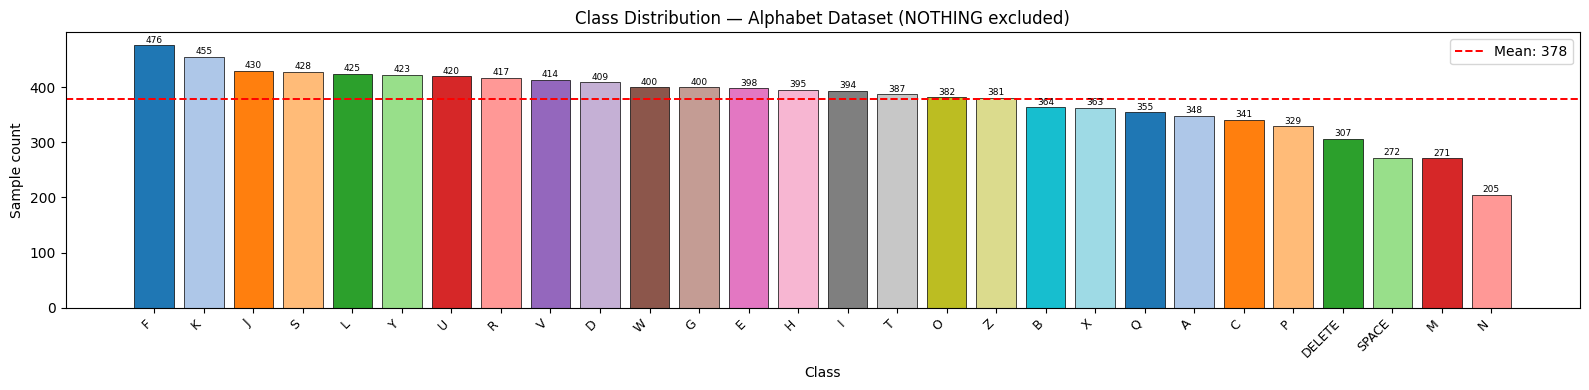

Total samples   : 10589
Num classes     : 28
Min per class   : 205 (N)
Max per class   : 476 (F)
Imbalance ratio : 2.32x


In [4]:
# Class distribution (after NOTHING drop)
class_counts = df['label'].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(16, 4))
colors_tab = [plt.cm.tab20.colors[i % 20] for i in range(len(class_counts))]
bars = ax.bar(range(len(class_counts)), class_counts.values,
              color=colors_tab, edgecolor='black', lw=0.5)
ax.set_xticks(range(len(class_counts)))
ax.set_xticklabels(class_counts.index, rotation=45, ha='right', fontsize=9)
ax.axhline(class_counts.mean(), ls='--', color='red', lw=1.4,
           label=f'Mean: {class_counts.mean():.0f}')
ax.set_xlabel('Class'); ax.set_ylabel('Sample count')
ax.set_title('Class Distribution — Alphabet Dataset (NOTHING excluded)')
ax.legend()
for bar, v in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1, str(v),
            ha='center', va='bottom', fontsize=6.5)
plt.tight_layout()
plt.savefig(LOG_OUT / 'eda_alphabet_class_distribution.png', dpi=150)
plt.show()

print(f'Total samples   : {len(df)}')
print(f'Num classes     : {df["label"].nunique()}')
print(f'Min per class   : {class_counts.min()} ({class_counts.idxmin()})')
print(f'Max per class   : {class_counts.max()} ({class_counts.idxmax()})')
print(f'Imbalance ratio : {class_counts.max()/class_counts.min():.2f}x')

Feature statistics (63 landmark dims):
          mean     std     min     max
lm0_x   0.0000  0.0000  0.0000  0.0000
lm0_y   0.0000  0.0000  0.0000  0.0000
lm0_z   0.0000  0.0000  0.0000  0.0000
lm1_x   0.1573  0.1203 -0.3830  0.4305
lm1_y  -0.0985  0.0886 -0.3681  0.2214
lm1_z  -0.0873  0.0672 -0.3527  0.2141
lm2_x   0.2378  0.2399 -0.6229  0.6948
lm2_y  -0.2527  0.1718 -0.6740  0.4686
lm2_z  -0.1259  0.1022 -0.5500  0.2829
lm3_x   0.1919  0.3283 -0.7992  0.8433
lm3_y  -0.3817  0.2484 -0.8704  0.6637
lm3_z  -0.1594  0.1236 -0.7302  0.2949
lm4_x   0.1107  0.3969 -0.9779  0.9435
lm4_y  -0.4427  0.3011 -0.9915  0.8094
lm4_z  -0.1880  0.1469 -0.9038  0.3314
lm5_x   0.1127  0.2642 -0.8422  0.7660
lm5_y  -0.4662  0.1561 -0.9952  0.6014
lm5_z  -0.0613  0.1269 -0.6786  0.3647
lm6_x   0.0916  0.3537 -0.9569  0.9220
lm6_y  -0.6076  0.2510 -0.9908  0.8443
lm6_z  -0.1390  0.1582 -0.8077  0.4102
lm7_x   0.0863  0.4006 -0.9923  0.9322
lm7_y  -0.6147  0.3030 -0.9839  0.9400
lm7_z  -0.1947  0.1751 -0

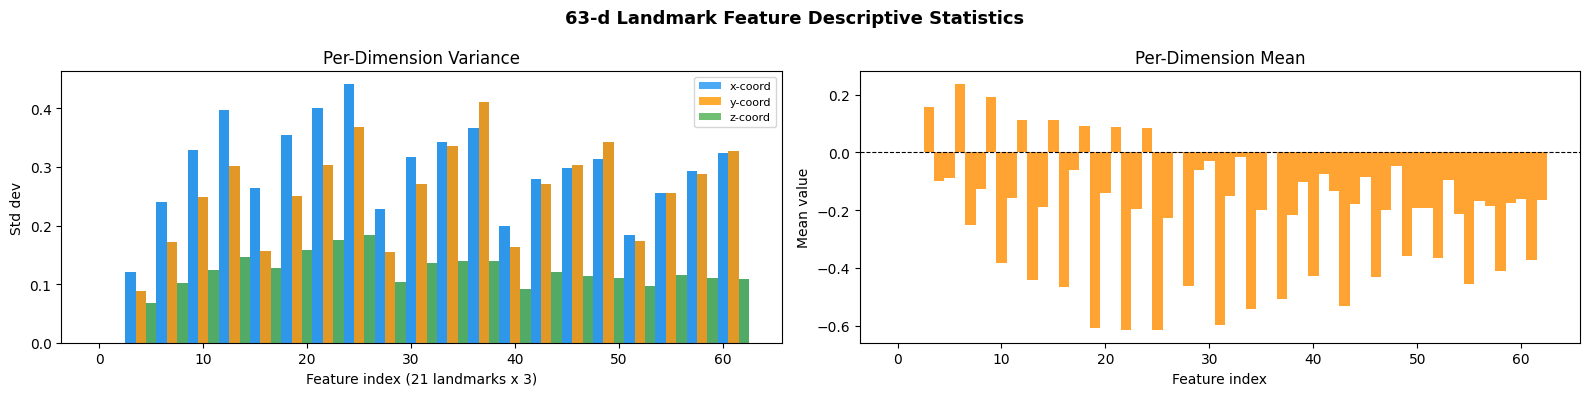

In [5]:
# Per-dimension descriptive statistics for the 63-d landmark features
X_all = np.stack(df['features'].values)  # (N, 63)

feat_df = pd.DataFrame(X_all, columns=[f'lm{i//3}_{"xyz"[i%3]}' for i in range(63)])
stats = feat_df.describe().T
print('Feature statistics (63 landmark dims):')
print(stats[['mean','std','min','max']].round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].bar(range(63), stats['std'], color='steelblue', alpha=0.8, width=1.0)
# Mark x, y, z groups
for start, color, label in [(0,'#2196F3','x'), (1,'#FF9800','y'), (2,'#4CAF50','z')]:
    axes[0].bar(range(start, 63, 3), stats['std'].values[start::3],
                color=color, alpha=0.8, width=1.0, label=f'{label}-coord')
axes[0].set_xlabel('Feature index (21 landmarks x 3)'); axes[0].set_ylabel('Std dev')
axes[0].set_title('Per-Dimension Variance'); axes[0].legend(fontsize=8)

axes[1].bar(range(63), stats['mean'], color='darkorange', alpha=0.8, width=1.0)
axes[1].set_xlabel('Feature index'); axes[1].set_ylabel('Mean value')
axes[1].set_title('Per-Dimension Mean')
axes[1].axhline(0, color='black', lw=0.8, ls='--')

plt.suptitle('63-d Landmark Feature Descriptive Statistics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(LOG_OUT / 'eda_alphabet_feature_stats.png', dpi=150)
plt.show()

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


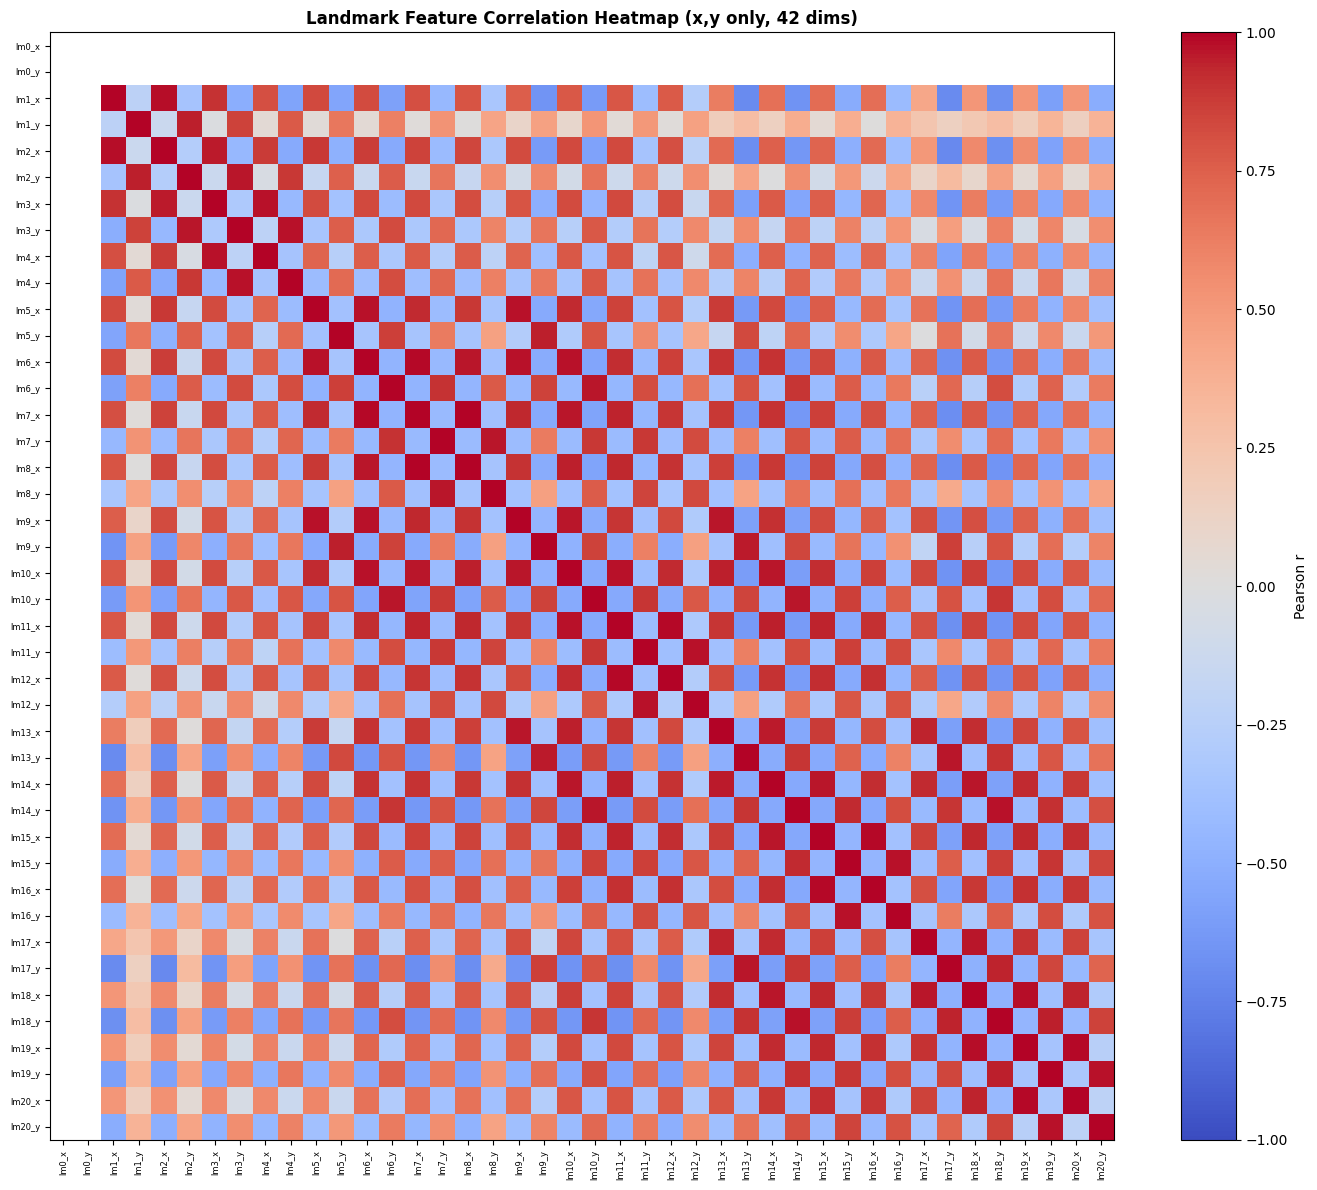

Highly correlated pairs (|r|>0.90): 74
  lm7_x      <-> lm8_x       r=0.9934
  lm19_x     <-> lm20_x      r=0.9908
  lm11_x     <-> lm12_x      r=0.9868
  lm15_x     <-> lm16_x      r=0.9865
  lm6_x      <-> lm7_x       r=0.9854
  lm1_x      <-> lm2_x       r=0.9784
  lm18_x     <-> lm19_x      r=0.9780
  lm3_x      <-> lm4_x       r=0.9746
  lm5_x      <-> lm9_x       r=0.9742
  lm19_y     <-> lm20_y      r=0.9739


In [6]:
# Landmark correlation heatmap (subsample for clarity: x,y per landmark = 42 dims)
xy_idx = [i for i in range(63) if i % 3 != 2]  # drop z coords -> 42 dims
col_labels = [f'lm{i//3}_{"xy"[i%3]}' for i in range(63) if i % 3 != 2]
X_xy = X_all[:, xy_idx]

corr = np.corrcoef(X_xy.T)  # (42, 42)

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Pearson r')
ax.set_xticks(range(42)); ax.set_yticks(range(42))
ax.set_xticklabels(col_labels, rotation=90, fontsize=6)
ax.set_yticklabels(col_labels, fontsize=6)
ax.set_title('Landmark Feature Correlation Heatmap (x,y only, 42 dims)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(LOG_OUT / 'eda_alphabet_correlation_heatmap.png', dpi=150)
plt.show()

# Report highly correlated pairs
corr_flat = corr.copy()
np.fill_diagonal(corr_flat, 0)
high_corr = [(col_labels[i], col_labels[j], corr_flat[i,j])
             for i in range(42) for j in range(i+1,42)
             if abs(corr_flat[i,j]) > 0.90]
high_corr.sort(key=lambda x: abs(x[2]), reverse=True)
print(f'Highly correlated pairs (|r|>0.90): {len(high_corr)}')
for a, b, r in high_corr[:10]:
    print(f'  {a:10s} <-> {b:10s}  r={r:.4f}')

## 2. Apply the saved train/val/test splits


In [3]:
orig_to_new = {orig: new for new, orig in enumerate(kept_indices)}

def remap(idx_list):
    return np.array([orig_to_new[i] for i in idx_list if i in orig_to_new])

train_idx = remap(splits['train_idx'])
val_idx   = remap(splits['val_idx'])
test_idx  = remap(splits['test_idx'])
print(f'train: {len(train_idx)}, val: {len(val_idx)}, test: {len(test_idx)}')

train: 8471, val: 1059, test: 1059


## 3. Encode string labels to integers


In [ ]:
labels_sorted = sorted(df['label'].unique())
label_to_idx = {lab: i for i, lab in enumerate(labels_sorted)}
idx_to_label = {i: lab for lab, i in label_to_idx.items()}

df['y'] = df['label'].map(label_to_idx)
X = np.stack(df['features'].values)        # (N, 63)
y = df['y'].to_numpy()

X_train, y_train = X[train_idx], y[train_idx]
X_val,   y_val   = X[val_idx],   y[val_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

print('Classes:', labels_sorted)
print(f'NUM_CLASSES = {len(labels_sorted)}')
print(f'Shapes — X_train: {X_train.shape}, y_train: {y_train.shape}')

# Save the  encoder for the server
with open(MODEL_OUT / 'label_encoder.pkl', 'wb') as f:
    pickle.dump({'label_to_idx': label_to_idx, 'idx_to_label': idx_to_label}, f)

Classes: ['A', 'B', 'C', 'D', 'DELETE', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'SPACE', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
NUM_CLASSES = 28
Shapes — X_train: (8471, 63), y_train: (8471,)


## 4. Class weights


In [5]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

print('Class weights (highest 5 — these classes get most loss attention):')
sorted_weights = sorted(class_weight_dict.items(), key=lambda x: x[1], reverse=True)
for cls, w in sorted_weights[:5]:
    print(f'  {idx_to_label[cls]:8s} weight={w:.3f}')

Class weights (highest 5 — these classes get most loss attention):
  N        weight=1.845
  M        weight=1.394
  SPACE    weight=1.388
  DELETE   weight=1.230
  P        weight=1.150


## 5. Data augmentation pipeline


In [6]:
def augment_landmarks(features, label):
    coords = tf.reshape(features, (21, 3))

    # Random horizontal flip (handedness augmentation) — 50% chance
    flip_sign = tf.where(tf.random.uniform([]) < 0.5, -1.0, 1.0)
    coords = tf.stack([coords[:, 0] * flip_sign, coords[:, 1], coords[:, 2]], axis=1)

    # Random rotation in xy plane
    angle = tf.random.uniform([], -0.26, 0.26)  # ~±15°
    cos_a, sin_a = tf.cos(angle), tf.sin(angle)
    x = coords[:, 0] * cos_a - coords[:, 1] * sin_a
    y_ = coords[:, 0] * sin_a + coords[:, 1] * cos_a
    coords = tf.stack([x, y_, coords[:, 2]], axis=1)
    # Random scale
    scale = tf.random.uniform([], 0.9, 1.1)
    coords *= scale
    # Random translation
    shift = tf.random.uniform([3], -0.05, 0.05)
    coords += shift
    # Light additive Gaussian noise
    coords += tf.random.normal(tf.shape(coords), stddev=0.01)
    return tf.reshape(coords, (63,)), label


BATCH = 256
train_ds = (tf.data.Dataset.from_tensor_slices((X_train.astype(np.float32), y_train))
            .map(augment_landmarks, num_parallel_calls=tf.data.AUTOTUNE)
            .shuffle(8192).batch(BATCH).prefetch(tf.data.AUTOTUNE))
val_ds   = (tf.data.Dataset.from_tensor_slices((X_val.astype(np.float32), y_val))
            .batch(BATCH).prefetch(tf.data.AUTOTUNE))
print('train_ds:', train_ds)

train_ds: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 63), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>


## 6. Model architecture


In [7]:
NUM_CLASSES = len(labels_sorted)

model = keras.Sequential([
    keras.layers.Input(shape=(63,)),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(NUM_CLASSES, activation='softmax'),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 28)             │         1,820 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,892 (237.86 KB)

 Trainable params: 60,124 (234.86 KB)

 Non-trainable params: 768 (3.00 KB)

## 7. Train


In [8]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                   restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4,
                                       min_lr=1e-6, verbose=1),
    keras.callbacks.ModelCheckpoint(str(MODEL_OUT / 'alphabet_model.h5'),
                                     monitor='val_accuracy', save_best_only=True),
    keras.callbacks.CSVLogger(str(LOG_OUT / 'alphabet_training.csv')),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=80,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=2,
)

Epoch 1/80


34/34 - 4s - 104ms/step - accuracy: 0.3317 - loss: 2.3830 - val_accuracy: 0.3768 - val_loss: 2.9392 - learning_rate: 1.0000e-03
Epoch 2/80


34/34 - 1s - 24ms/step - accuracy: 0.6735 - loss: 1.1525 - val_accuracy: 0.4740 - val_loss: 2.5515 - learning_rate: 1.0000e-03
Epoch 3/80
34/34 - 1s - 23ms/step - accuracy: 0.7860 - loss: 0.7429 - val_accuracy: 0.3853 - val_loss: 2.3133 - learning_rate: 1.0000e-03
Epoch 4/80
34/34 - 1s - 22ms/step - accuracy: 0.8298 - loss: 0.5823 - val_accuracy: 0.3484 - val_loss: 2.1436 - learning_rate: 1.0000e-03
Epoch 5/80
34/34 - 1s - 23ms/step - accuracy: 0.8541 - loss: 0.4997 - val_accuracy: 0.4297 - val_loss: 1.9106 - learning_rate: 1.0000e-03
Epoch 6/80
34/34 - 1s - 23ms/step - accuracy: 0.8662 - loss: 0.4432 - val_accuracy: 0.4712 - val_loss: 1.7037 - learning_rate: 1.0000e-03
Epoch 7/80


34/34 - 1s - 24ms/step - accuracy: 0.8746 - loss: 0.4060 - val_accuracy: 0.5260 - val_loss: 1.4356 - learning_rate: 1.0000e-03
Epoch 8/80


34/34 - 1s - 24ms/step - accuracy: 0.8951 - loss: 0.3632 - val_accuracy: 0.7054 - val_loss: 1.1271 - learning_rate: 1.0000e-03
Epoch 9/80


...

34/34 - 1s - 24ms/step - accuracy: 0.9549 - loss: 0.1482 - val_accuracy: 0.9783 - val_loss: 0.0700 - learning_rate: 5.0000e-04
Epoch 39/80


34/34 - 1s - 24ms/step - accuracy: 0.9564 - loss: 0.1462 - val_accuracy: 0.9792 - val_loss: 0.0680 - learning_rate: 5.0000e-04
Epoch 40/80


34/34 - 1s - 24ms/step - accuracy: 0.9563 - loss: 0.1447 - val_accuracy: 0.9802 - val_loss: 0.0717 - learning_rate: 5.0000e-04
Epoch 41/80
34/34 - 1s - 23ms/step - accuracy: 0.9574 - loss: 0.1415 - val_accuracy: 0.9773 - val_loss: 0.0721 - learning_rate: 5.0000e-04
Epoch 42/80
34/34 - 1s - 23ms/step - accuracy: 0.9599 - loss: 0.1399 - val_accuracy: 0.9783 - val_loss: 0.0689 - learning_rate: 5.0000e-04
Epoch 43/80

Epoch 43: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
34/34 - 1s - 22ms/step - accuracy: 0.9581 - loss: 0.1440 - val_accuracy: 0.9802 - val_loss: 0.0704 - learning_rate: 5.0000e-04
Epoch 44/80
34/34 - 1s - 23ms/step - accuracy: 0.9610 - loss: 0.1366 - val_accuracy: 0.9783 - val_loss: 0.0683 - learning_rate: 2.5000e-04
Epoch 45/80
34/34 - 1s - 23ms/step - accuracy: 0.9573 - loss: 0.1341 - val_accuracy: 0.9792 - val_loss: 0.0699 - learning_rate: 2.5000e-04
Epoch 46/80


34/34 - 1s - 25ms/step - accuracy: 0.9601 - loss: 0.1303 - val_accuracy: 0.9821 - val_loss: 0.0680 - learning_rate: 2.5000e-04
Epoch 47/80

Epoch 47: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
34/34 - 1s - 23ms/step - accuracy: 0.9626 - loss: 0.1222 - val_accuracy: 0.9754 - val_loss: 0.0683 - learning_rate: 2.5000e-04
Epoch 48/80
34/34 - 1s - 24ms/step - accuracy: 0.9623 - loss: 0.1279 - val_accuracy: 0.9773 - val_loss: 0.0659 - learning_rate: 1.2500e-04
Epoch 49/80
34/34 - 1s - 24ms/step - accuracy: 0.9626 - loss: 0.1187 - val_accuracy: 0.9802 - val_loss: 0.0649 - learning_rate: 1.2500e-04
Epoch 50/80
34/34 - 1s - 23ms/step - accuracy: 0.9668 - loss: 0.1173 - val_accuracy: 0.9802 - val_loss: 0.0636 - learning_rate: 1.2500e-04
Epoch 51/80
34/34 - 1s - 23ms/step - accuracy: 0.9622 - loss: 0.1252 - val_accuracy: 0.9792 - val_loss: 0.0635 - learning_rate: 1.2500e-04
Epoch 52/80
34/34 - 1s - 23ms/step - accuracy: 0.9658 - loss: 0.1154 - val_accuracy: 0.9802 - val_lo

34/34 - 1s - 25ms/step - accuracy: 0.9651 - loss: 0.1131 - val_accuracy: 0.9839 - val_loss: 0.0629 - learning_rate: 6.2500e-05
Epoch 57/80
34/34 - 1s - 23ms/step - accuracy: 0.9681 - loss: 0.1127 - val_accuracy: 0.9830 - val_loss: 0.0621 - learning_rate: 6.2500e-05
Epoch 58/80
34/34 - 1s - 24ms/step - accuracy: 0.9652 - loss: 0.1142 - val_accuracy: 0.9830 - val_loss: 0.0631 - learning_rate: 6.2500e-05
Epoch 59/80
34/34 - 1s - 24ms/step - accuracy: 0.9671 - loss: 0.1100 - val_accuracy: 0.9830 - val_loss: 0.0627 - learning_rate: 6.2500e-05
Epoch 60/80
34/34 - 1s - 23ms/step - accuracy: 0.9661 - loss: 0.1157 - val_accuracy: 0.9830 - val_loss: 0.0628 - learning_rate: 6.2500e-05
Epoch 61/80

Epoch 61: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
34/34 - 1s - 24ms/step - accuracy: 0.9633 - loss: 0.1173 - val_accuracy: 0.9811 - val_loss: 0.0626 - learning_rate: 6.2500e-05
Epoch 62/80
34/34 - 1s - 23ms/step - accuracy: 0.9640 - loss: 0.1210 - val_accuracy: 0.9830 - val_lo

## 8. Training curves


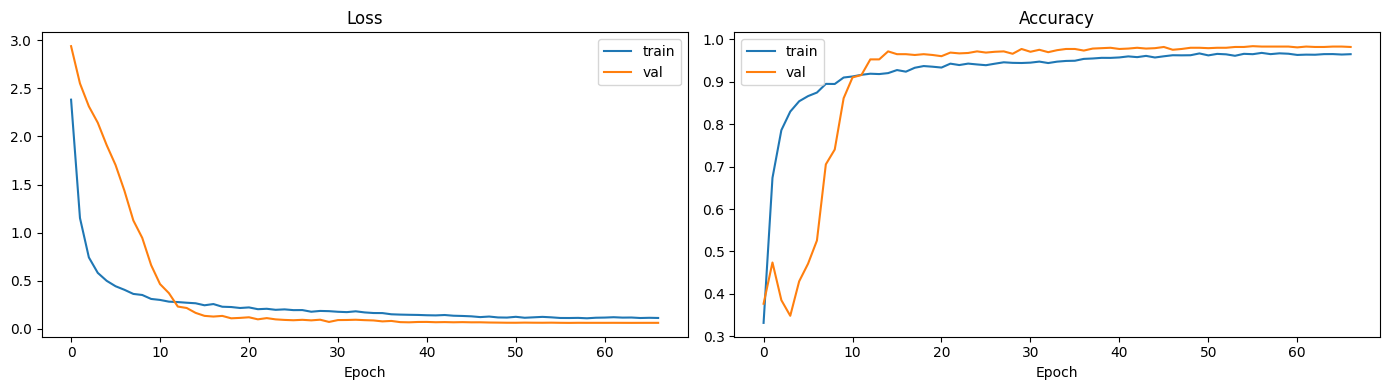

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.savefig(LOG_OUT / 'alphabet_training_curves.png', dpi=150)
plt.show()

## 9. Evaluate on the held-out test set


In [10]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred_proba = model.predict(X_test.astype(np.float32), batch_size=BATCH, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

test_acc = accuracy_score(y_test, y_pred)
print(f'Test accuracy: {test_acc:.4f}')

label_names = [idx_to_label[i] for i in sorted(idx_to_label)]
report = classification_report(y_test, y_pred, target_names=label_names,
                                output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
report_df.to_csv(LOG_OUT / 'alphabet_classification_report.csv')
print('\nClassification report (per-class):')
print(classification_report(y_test, y_pred, target_names=label_names, zero_division=0))

Test accuracy: 0.9792

Classification report (per-class):
              precision    recall  f1-score   support

           A       1.00      0.94      0.97        35
           B       0.92      1.00      0.96        36
           C       0.94      1.00      0.97        34
           D       1.00      0.95      0.97        41
      DELETE       1.00      1.00      1.00        31
           E       0.97      0.95      0.96        40
           F       0.98      1.00      0.99        47
           G       1.00      1.00      1.00        40
           H       0.98      1.00      0.99        40
           I       1.00      0.95      0.97        40
           J       1.00      0.98      0.99        43
           K       1.00      1.00      1.00        45
           L       1.00      1.00      1.00        43
           M       0.87      0.96      0.91        27
           N       0.95      0.95      0.95        21
           O       0.97      0.95      0.96        38
           P       1.00

## 10. Confusion matrix


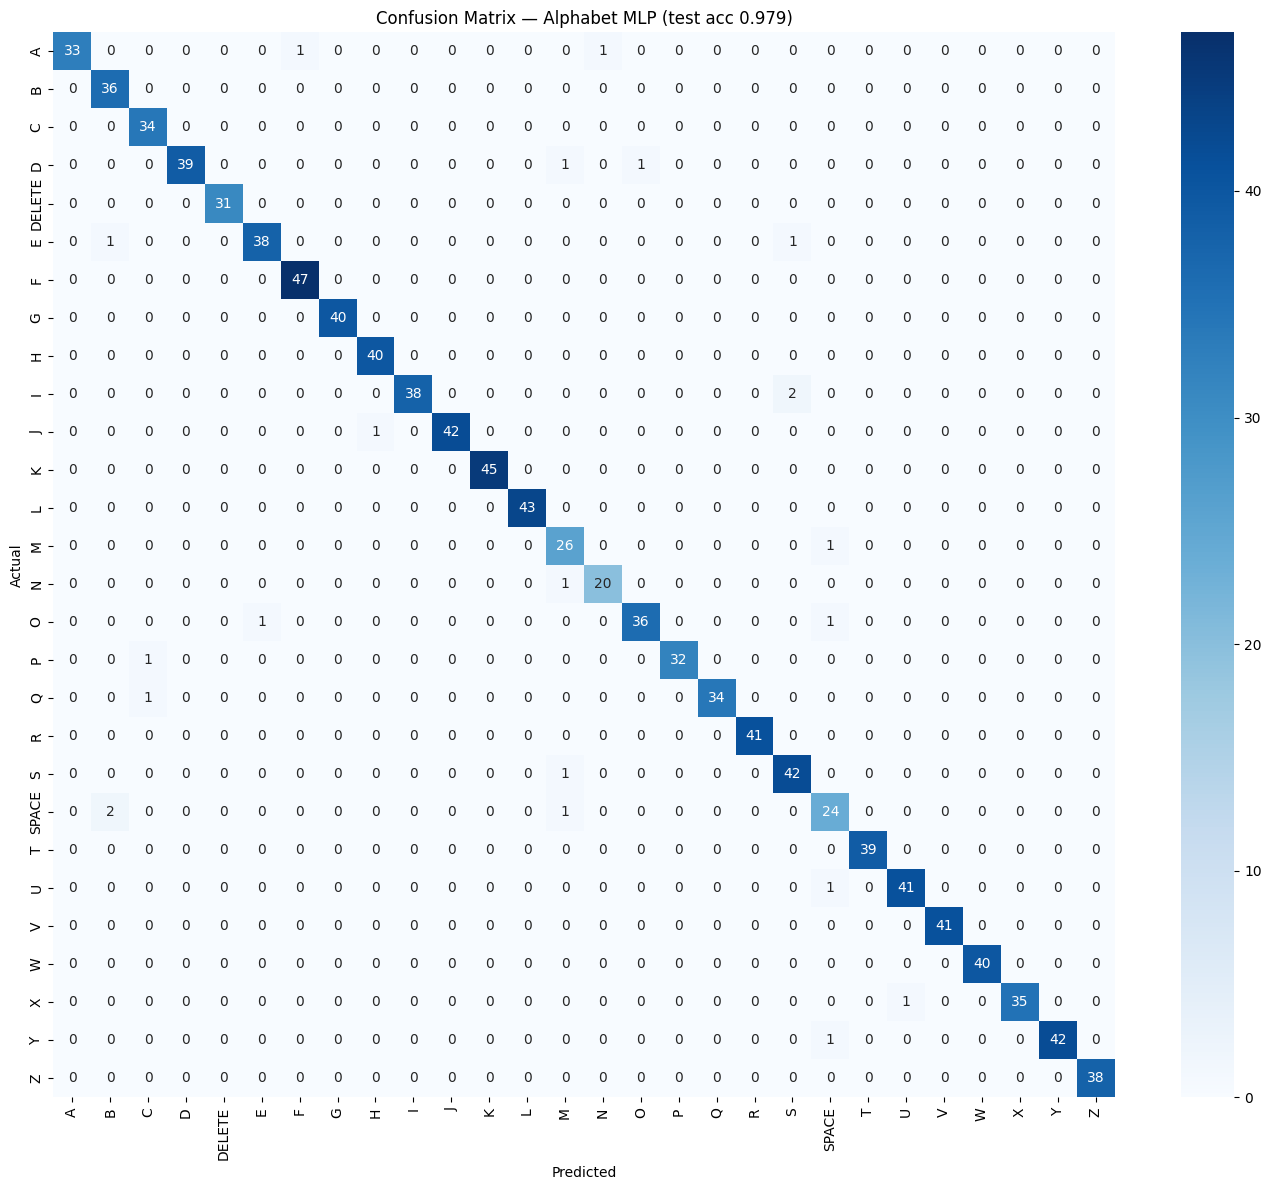

In [11]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_names, yticklabels=label_names,
            cmap='Blues', ax=ax)
ax.set_title(f'Confusion Matrix — Alphabet MLP (test acc {test_acc:.3f})')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(LOG_OUT / 'alphabet_confusion_matrix.png', dpi=150)
plt.show()

## 11. Identify weak classes and confused pairs


In [12]:
weak = [(lab, report[lab]['f1-score'])
        for lab in label_names if report[lab]['f1-score'] < 0.80]
weak.sort(key=lambda x: x[1])
print('Weak classes (F1 < 0.80):')
for lab, f1 in weak:
    print(f'  {lab:8s} F1={f1:.3f}')
if not weak:
    print('  (none — all classes above 0.80)')

print('\nMost-confused pairs (>10% of a class misclassified to another):')
for i, true_lab in enumerate(label_names):
    total = cm[i].sum()
    if total == 0: continue
    for j, pred_lab in enumerate(label_names):
        if i != j and cm[i][j] > 0.10 * total:
            pct = 100 * cm[i][j] / total
            print(f'  {true_lab} → {pred_lab}: {cm[i][j]} ({pct:.1f}%)')

Weak classes (F1 < 0.80):
  (none — all classes above 0.80)

Most-confused pairs (>10% of a class misclassified to another):


## 12. Convert to TFLite


In [13]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_bytes = converter.convert()

tflite_path = MODEL_OUT / 'alphabet_model.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_bytes)
print(f'Saved {tflite_path}, {tflite_path.stat().st_size/1e3:.1f} KB')

# Parity check
interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
interpreter.allocate_tensors()
in_det  = interpreter.get_input_details()[0]
out_det = interpreter.get_output_details()[0]

n_match = 0
for i in range(20):
    sample = X_test[i:i+1].astype(np.float32)
    interpreter.set_tensor(in_det['index'], sample)
    interpreter.invoke()
    tflite_pred = np.argmax(interpreter.get_tensor(out_det['index']))
    keras_pred  = np.argmax(model.predict(sample, verbose=0))
    n_match += int(tflite_pred == keras_pred)
print(f'TFLite/Keras agreement on 20 test samples: {n_match}/20')

INFO:tensorflow:Assets written to: /tmp/tmp4ufxr84p/assets


INFO:tensorflow:Assets written to: /tmp/tmp4ufxr84p/assets


Saved artifact at '/tmp/tmp4ufxr84p'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 63), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 28), dtype=tf.float32, name=None)
Captures:
  134646660052560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134646660054672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134646660052752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134646660054864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134646660052368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134646660053136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134646660053904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134646660053328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134646624028240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134646624028432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134646624028048: Tenso

W0000 00:00:1777699255.515524      57 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777699255.515577      57 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1777699255.529784      57 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Saved /kaggle/working/models/alphabet_model.tflite, 69.3 KB
TFLite/Keras agreement on 20 test samples: 20/20
